Classification multi-alogorithmes sur Iris


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

On charge les donnée 

In [5]:
iris = load_iris()
X, y = iris.data, iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


Définition des piplelines 

In [6]:
pipelines = {
    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("clf",    KNeighborsClassifier(n_neighbors=5)),
    ]),
    "Arbre": Pipeline([
        ("scaler", StandardScaler()),
        ("clf",    DecisionTreeClassifier(max_depth=5, random_state=42)),
    ]),
    "Random Forest": Pipeline([
        ("scaler", StandardScaler()),
        ("clf",    RandomForestClassifier(n_estimators=100, random_state=42)),
    ]),
}

Entraînement et évaluation

In [7]:
results = {}

for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc

    print(f"\n{'='*40}")
    print(f"  {name}  —  accuracy : {acc:.4f}")
    print('='*40)
    print(classification_report(y_test, y_pred, target_names=iris.target_names))


  KNN  —  accuracy : 0.9333
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.83      1.00      0.91        10
   virginica       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30


  Arbre  —  accuracy : 0.9333
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30


  Random Forest  —  accuracy : 0.9000
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.82      0

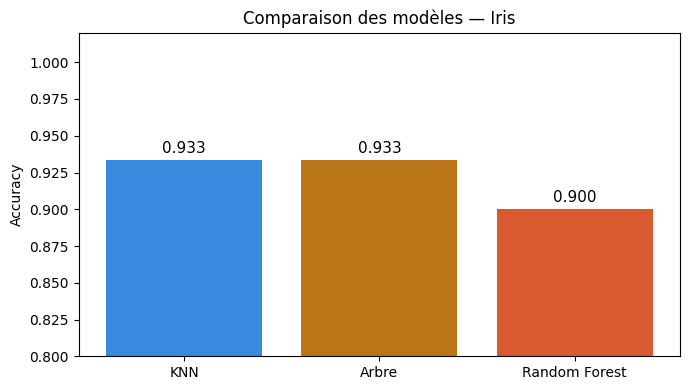

In [8]:
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(results.keys(), results.values(), color=["#378ADD", "#BA7517", "#D85A30"])
ax.set_ylim(0.8, 1.02)
ax.set_ylabel("Accuracy")
ax.set_title("Comparaison des modèles — Iris")
for bar, val in zip(bars, results.values()):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.003,
            f"{val:.3f}", ha="center", va="bottom", fontsize=11)
plt.tight_layout()
plt.show()

comparaison  accuracy

In [9]:
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

Entraînement + collecte des métriques

In [10]:
metrics = {}

for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    metrics[name] = {
        "accuracy": accuracy_score(y_test, y_pred),
        "f1_macro": f1_score(y_test, y_pred, average="macro"),
        "y_pred":   y_pred,
    }


Tableau comparatif accuracy & f1-macro

In [13]:
print(f"{'Modèle':<20} {'Accuracy':>10} {'F1-macro':>10}")
print("-" * 42)
for name, m in metrics.items():
    print(f"{name:<20} {m['accuracy']:>10.4f} {m['f1_macro']:>10.4f}")




Modèle                 Accuracy   F1-macro
------------------------------------------
KNN                      0.9333     0.9327
Arbre                    0.9333     0.9333
Random Forest            0.9000     0.8997


Bar chart côte à côte

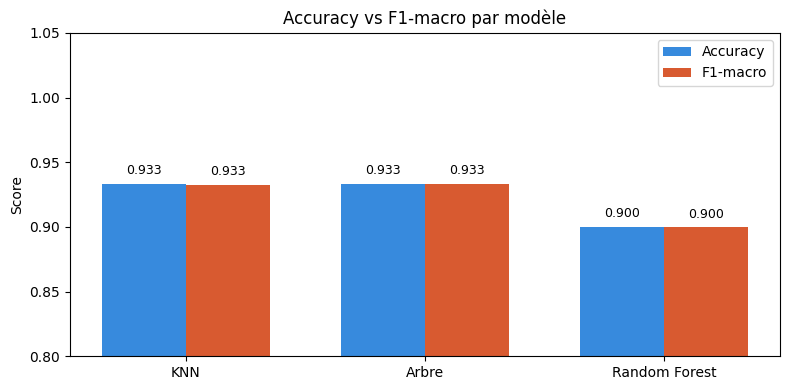

In [ ]:

noms    = list(metrics.keys())
acc     = [metrics[n]["accuracy"] for n in noms]
f1      = [metrics[n]["f1_macro"] for n in noms]

x  = np.arange(len(noms))
w  = 0.35

fig, ax = plt.subplots(figsize=(8, 4))
b1 = ax.bar(x - w/2, acc, w, label="Accuracy",  color="#378ADD")
b2 = ax.bar(x + w/2, f1,  w, label="F1-macro",  color="#D85A30")

ax.set_ylim(0.8, 1.05)
ax.set_xticks(x)
ax.set_xticklabels(noms)
ax.set_ylabel("Score")
ax.set_title("Accuracy vs F1-macro par modèle")
ax.legend()
for bar in b1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=9)
for bar in b2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

Matrices de confusion (1 ligne, 3 plots)

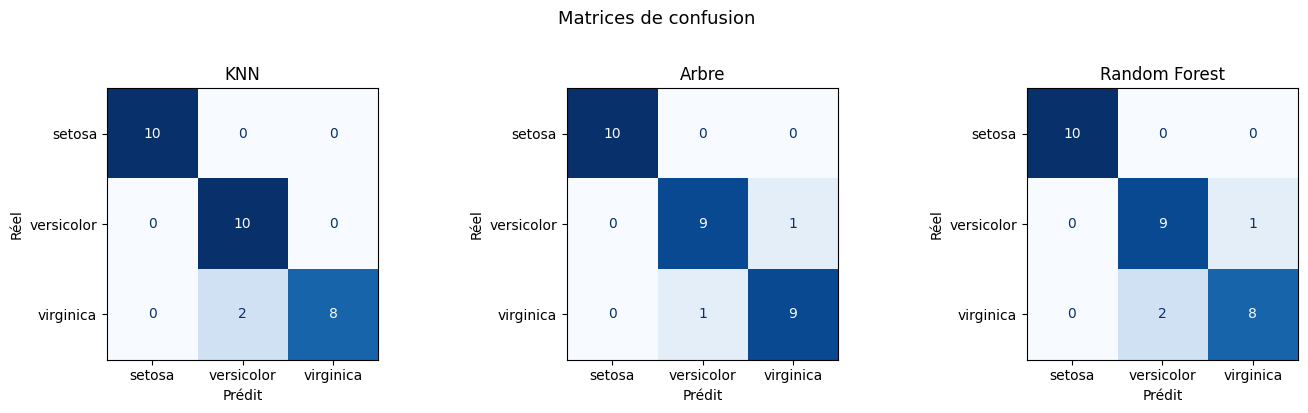

In [12]:
ig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, (name, m) in zip(axes, metrics.items()):
    cm = confusion_matrix(y_test, m["y_pred"])
    disp = ConfusionMatrixDisplay(cm, display_labels=iris.target_names)
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(name)
    ax.set_xlabel("Prédit")
    ax.set_ylabel("Réel")

plt.suptitle("Matrices de confusion", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [19]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

Cross-validation 5 folds

In [20]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = {}

print(f"{'Modèle':<20} {'Acc moyenne':>12} {'Std':>8} {'F1 moyenne':>12} {'Std':>8}")
print("-" * 65)

for name, pipe in pipelines.items():
    acc_scores = cross_val_score(pipe, X, y, cv=cv, scoring="accuracy")
    f1_scores  = cross_val_score(pipe, X, y, cv=cv, scoring="f1_macro")

    cv_results[name] = {
        "acc_mean": acc_scores.mean(),
        "acc_std":  acc_scores.std(),
        "f1_mean":  f1_scores.mean(),
        "f1_std":   f1_scores.std(),
        "acc_scores": acc_scores,
    }

    print(f"{name:<20} {acc_scores.mean():>12.4f} {acc_scores.std():>8.4f} "
          f"{f1_scores.mean():>12.4f} {f1_scores.std():>8.4f}")

Modèle                Acc moyenne      Std   F1 moyenne      Std
-----------------------------------------------------------------
KNN                        0.9733   0.0249       0.9733   0.0250
Arbre                      0.9467   0.0267       0.9464   0.0268
Random Forest              0.9467   0.0267       0.9464   0.0268


Boxplot des scores par fold 

/var/folders/bg/36y8k9sn4r90mjdwrm9r0gx00000gn/T/ipykernel_40608/4205458931.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=noms, patch_artist=True,


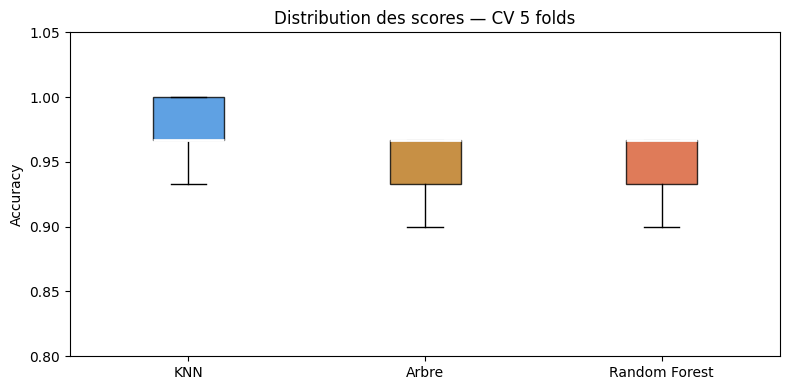

In [21]:
fig, ax = plt.subplots(figsize=(8, 4))

data  = [cv_results[n]["acc_scores"] for n in cv_results]
noms  = list(cv_results.keys())

bp = ax.boxplot(data, labels=noms, patch_artist=True,
                medianprops=dict(color="white", linewidth=2))

colors = ["#378ADD", "#BA7517", "#D85A30"]
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)

ax.set_ylabel("Accuracy")
ax.set_title("Distribution des scores — CV 5 folds")
ax.set_ylim(0.8, 1.05)
plt.tight_layout()
plt.show()

Identification du meilleur modèle

In [22]:
meilleur = max(cv_results, key=lambda n: (
    cv_results[n]["acc_mean"] + cv_results[n]["f1_mean"]
) / 2)

m = cv_results[meilleur]
print(f"\n✔ Meilleur modèle : {meilleur}")
print(f"  Accuracy moyenne : {m['acc_mean']:.4f} ± {m['acc_std']:.4f}")
print(f"  F1-macro moyenne : {m['f1_mean']:.4f} ± {m['f1_std']:.4f}")


✔ Meilleur modèle : KNN
  Accuracy moyenne : 0.9733 ± 0.0249
  F1-macro moyenne : 0.9733 ± 0.0250


justification 

Le meilleure modèle est celui qui on un score élevé. Dans Iris , Random Forest obtien un score plus élevés donc un meilleur résultat grace à l'agrégation de plusieurs abres qui réduit le surapprentisage. KNN est sensible à l'échelle et l'abres seul tend à avoir une variance plus élevée entre fold   